# RoadVision

# Model Inference and Qualitative Analysis

This notebook demonstrates qualitative evaluation of the trained YOLO11 Nano model by performing inference on unseen road images from the test dataset.

## Objectives

- Load the trained YOLO11 Nano model
- Perform inference on unseen road images
- Visualize predicted detections
- Analyze qualitative prediction results
- Summarize model inference performance

In [1]:
from pathlib import Path

import random

import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from ultralytics import YOLO

## Project Paths

In [2]:
PROJECT_ROOT = Path("../../").resolve()

TEST_IMAGES = (
    PROJECT_ROOT
    / "datasets"
    / "rdd2022"
    / "test"
    / "images"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "model"
    / "runs"
    / "baseline_yolo11n"
    / "weights"
    / "best.pt"
)

In [3]:
print(MODEL_PATH)

C:\Projects\road-damage-detection\model\runs\baseline_yolo11n\weights\best.pt


## Load Trained Model

In [4]:
model = YOLO(MODEL_PATH)

## Select Test Image

In [42]:
test_images = list(TEST_IMAGES.glob("*.jpg"))

random.shuffle(test_images)

selected_predictions = []

MAX_IMAGES = 3

for image_path in test_images:

    results = model.predict(
        source=image_path,
        conf=0.25,
        save=False,
        verbose=False
    )

    if len(results[0].boxes) > 0:
        selected_predictions.append((image_path, results))

    if len(selected_predictions) == MAX_IMAGES:
        break

print(f"Images with detections found: {len(selected_predictions)}")

Images with detections found: 3


## Qualitative Prediction Analysis

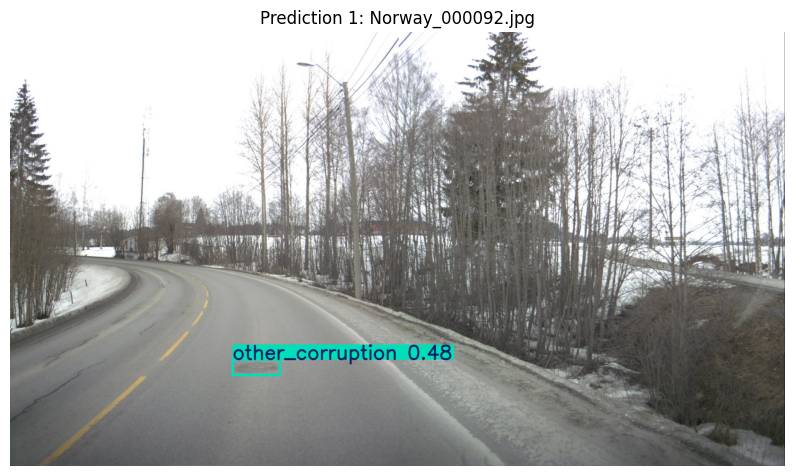

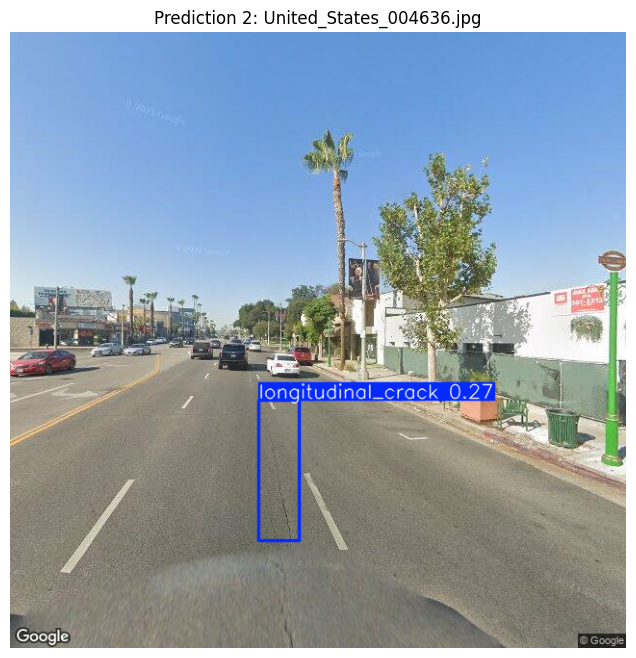

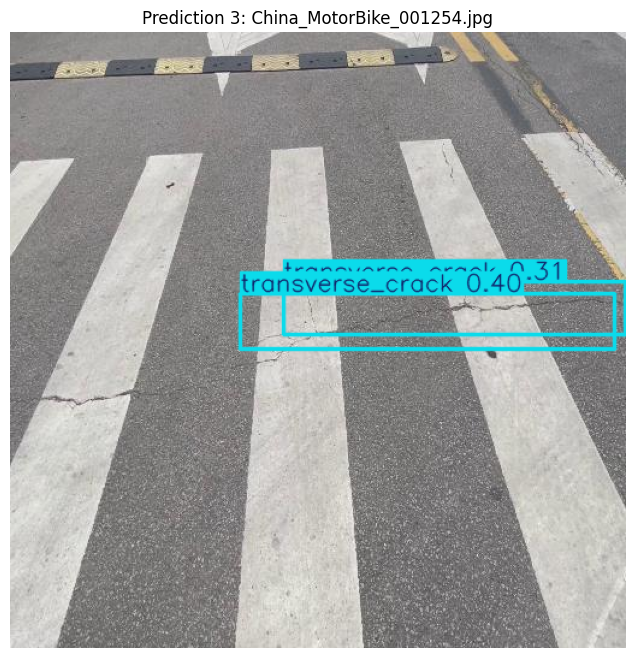

In [43]:
prediction_summary = []

if len(selected_predictions) == 0:

    print("No detections were found using the current baseline model.")

else:

    for index, (image_path, results) in enumerate(selected_predictions, start=1):

        prediction = results[0].plot()

        plt.figure(figsize=(10,8))

        plt.imshow(prediction[:, :, ::-1])

        plt.title(f"Prediction {index}: {image_path.name}")

        plt.axis("off")

        plt.show()

        boxes = results[0].boxes

        prediction_summary.append({
            "Image": image_path.name,
            "Objects Detected": len(boxes),
            "Highest Confidence": round(float(boxes.conf.max()), 3)
        })

### Observation

The baseline YOLO11 Nano model successfully performed inference on unseen test images. Depending on the strength of the baseline model, the number of detected road damage instances may vary. When detections are produced, the predicted bounding boxes, class labels, and confidence scores demonstrate the model's ability to localize road damage on previously unseen images.

## Prediction Summary

In [53]:
from IPython.display import display

if len(prediction_summary) > 0:

    prediction_summary = pd.DataFrame(prediction_summary)

    display(prediction_summary)

else:

    print("Prediction summary unavailable because no detections were produced.")

,Image,Objects Detected,Highest Confidence
0,Norway_000092.jpg,1,0.485
1,United_States_004636.jpg,1,0.271
2,China_MotorBike_001254.jpg,2,0.399


### Observation

The prediction summary provides a consolidated overview of inference performance across multiple unseen road images. The number of detections and associated confidence scores offer a qualitative assessment of the baseline model's performance on previously unseen data.

# Final Summary

The trained YOLO11 Nano model successfully performed inference on unseen road images using the complete RoadVision pipeline. The qualitative predictions demonstrate that the trained model can process new inputs and generate road damage detections. While this baseline model was trained on a reduced development dataset, the inference workflow is fully validated and ready for production-scale training and backend integration.